<a href="https://colab.research.google.com/github/naveenkumars386606-cpu/Machine-Learning/blob/main/TimeSeriesHandson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/AirPassengers.csv")

In [ ]:
df

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [ ]:
df.isnull().sum()

,0
Month,0
#Passengers,0


In [ ]:
df["Month"] = pd.to_datetime(df["Month"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        144 non-null    datetime64[ns]
 1   #Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


In [ ]:
df.set_index("Month",inplace=True)

In [ ]:
df

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


Figure(640x480)


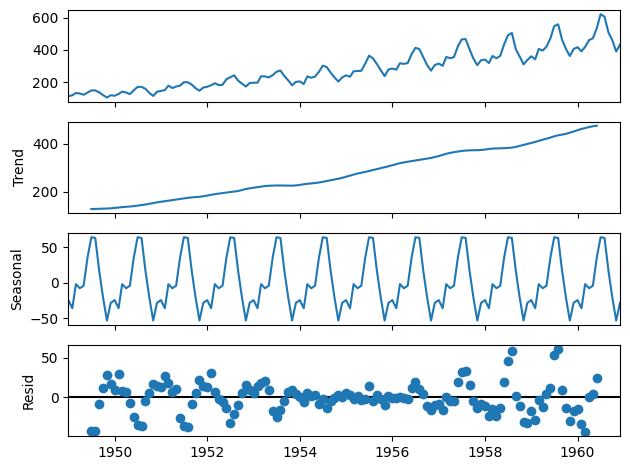

In [ ]:
#seasonal decompositional
#trend
#seasonaliity
#residual/noice
from statsmodels.tsa.seasonal import seasonal_decompose
decomposed = seasonal_decompose(df)
print(decomposed.plot())

In [ ]:
#Non stationary?
#verify?
#Augmented Dicky Fuller Test

In [ ]:
from statsmodels.tsa.stattools import adfuller


In [ ]:
result = adfuller(df)
result

(np.float64(0.8153688792060498),
 np.float64(0.991880243437641),
 13,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(996.692930839019))

In [ ]:
pval = result[1]
if pval > 0.05:
  print("Non stationary",pval)
else:
  print("Stationary",pval)

Non stationary 0.991880243437641


In [ ]:
#differncing

In [ ]:
dummy_df = df.copy()

In [ ]:
dummy_df

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [ ]:
#first order differencing

In [ ]:
first_diff = dummy_df.diff().dropna()

In [ ]:
first_diff

,#Passengers
Month,
1949-02-01,6.0
1949-03-01,14.0
1949-04-01,-3.0
1949-05-01,-8.0
1949-06-01,14.0
...,...
1960-08-01,-16.0
1960-09-01,-98.0
1960-10-01,-47.0


In [ ]:
result = adfuller(first_diff)
result[1]

np.float64(0.05421329028382478)

In [ ]:
#second order
second_diff = first_diff.diff().dropna()

In [ ]:
second_diff.head()

,#Passengers
Month,
1949-03-01,8.0
1949-04-01,-17.0
1949-05-01,-5.0
1949-06-01,22.0
1949-07-01,-1.0


In [ ]:
result = adfuller(second_diff)
result[1]

np.float64(2.7328918500142026e-29)

<Axes: xlabel='Month'>

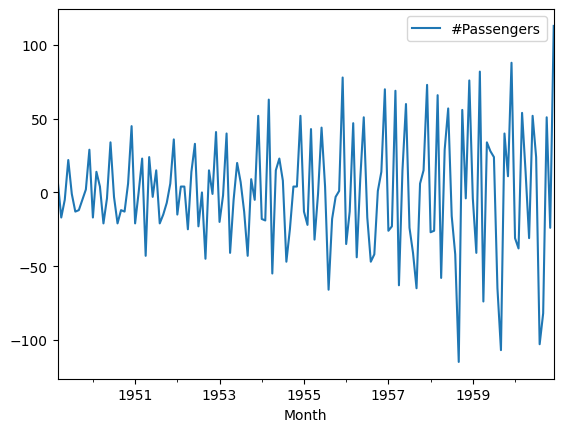

In [ ]:
second_diff.plot()

In [ ]:
first_log = np.log(dummy_df)
first_log.head()

,#Passengers
Month,
1949-01-01,4.718499
1949-02-01,4.770685
1949-03-01,4.882802
1949-04-01,4.859812
1949-05-01,4.795791


In [ ]:
result = adfuller(first_log)
result[1]

np.float64(0.4223667747703874)

<Axes: xlabel='Month'>

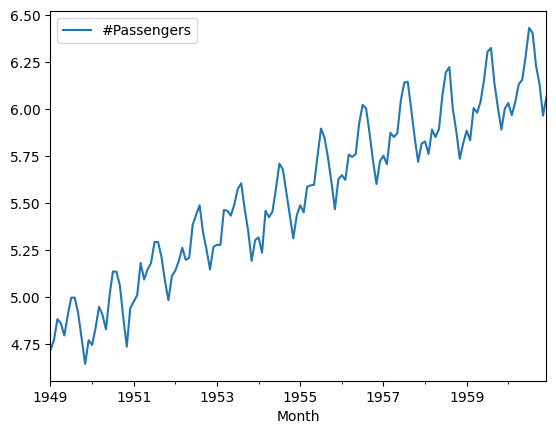

In [ ]:
first_log.plot()

In [ ]:
mean_log = first_log.rolling(window=12).mean()

In [ ]:
mean_log

,#Passengers
Month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN
...,...
1960-08-01,6.124517
1960-09-01,6.132246
1960-10-01,6.142628


In [ ]:
#differencing => first_log - mean_log
#log transformation + Rollingmean + differecing

In [ ]:
newdata = first_log - mean_log

In [ ]:
newdata

,#Passengers
Month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN
...,...
1960-08-01,0.282363
1960-09-01,0.098235
1960-10-01,-0.009230


In [ ]:
newdata.dropna(inplace=True)

In [ ]:
newdata

,#Passengers
Month,
1949-12-01,-0.065494
1950-01-01,-0.093449
1950-02-01,-0.007566
1950-03-01,0.099416
1950-04-01,0.052142
...,...
1960-08-01,0.282363
1960-09-01,0.098235
1960-10-01,-0.009230


In [ ]:
result = adfuller(newdata)
result[1]

np.float64(0.022234630001242206)

<Axes: xlabel='Month'>

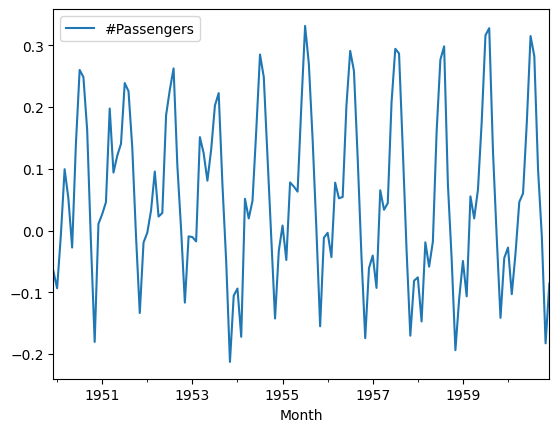

In [ ]:
newdata.plot()

In [ ]:
train = newdata[:120]
test = newdata[120:]

In [ ]:
train

,#Passengers
Month,
1949-12-01,-0.065494
1950-01-01,-0.093449
1950-02-01,-0.007566
1950-03-01,0.099416
1950-04-01,0.052142
...,...
1959-07-01,0.316430
1959-08-01,0.327838
1959-09-01,0.128057


In [ ]:
test

,#Passengers
Month,
1959-12-01,-0.044481
1960-01-01,-0.027530
1960-02-01,-0.103067
1960-03-01,-0.036530
1960-04-01,0.046332
1960-05-01,0.060186
1960-06-01,0.175033
1960-07-01,0.315151
1960-08-01,0.282363


AR(Auto Regression) model

In [ ]:
#Partial autocorrelation function => help to choose the p value

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf

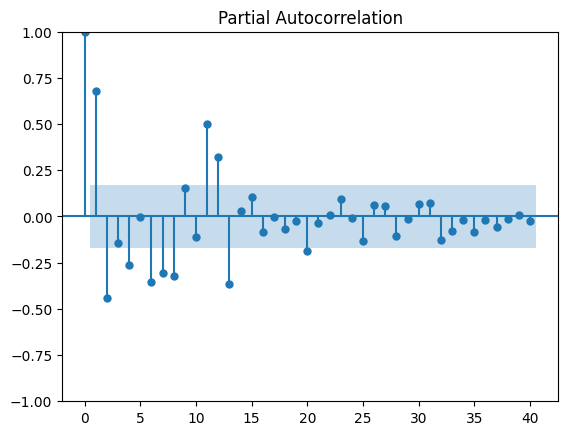

In [ ]:
plot_pacf(newdata,lags=40)
plt.show()

In [ ]:
from statsmodels.tsa.ar_model import AutoReg

In [ ]:
model = AutoReg(train,lags=7)
modelfit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
modelfit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            AutoReg Model Results                             
==============================================================================
Dep. Variable:            #Passengers   No. Observations:                  120
Model:                     AutoReg(7)   Log Likelihood                 134.117
Method:               Conditional MLE   S.D. of innovations              0.074
Date:                Wed, 29 Apr 2026   AIC                           -250.233
Time:                        02:48:57   BIC                           -225.687
Sample:                    07-01-1950   HQIC                          -240.273
                         - 11-01-1959                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.0671      0.010      6.411      0.000       0.047       0.088
#Passengers.L1     0.7660      0.088      8.710      0.000       0.594       0.938
#Passengers.L2    -0.3319      0.112     -2.974      0.003      -0.551      -0.113
#Passengers.L3    -0.0288      0.115     -0.251      0.802      -0.254       0.196
#Passengers.L4    -0.3700      0.110     -3.358      0.001      -0.586      -0.154
#Passengers.L5     0.1891      0.116      1.637      0.102      -0.037       0.416
#Passengers.L6    -0.0759      0.112     -0.677      0.498      -0.296       0.144
#Passengers.L7    -0.3334      0.089     -3.762      0.000      -0.507      -0.160
                                    Roots                                    
=============================================================================
                  Real          Imaginary           Modulus         Frequency
-----------------------------------------------------------------------------
AR.1            0.9016           -0.5156j            1.0386           -0.0827
AR.2            0.9016           +0.5156j            1.0386            0.0827
AR.3            0.4784           -1.0247j            1.1309           -0.1805
AR.4            0.4784           +1.0247j            1.1309            0.1805
AR.5           -0.7017           -0.9381j            1.1715           -0.3522
AR.6           -0.7017           +0.9381j            1.1715            0.3522
AR.7           -1.5843           -0.0000j            1.5843           -0.5000
-----------------------------------------------------------------------------
"""

In [ ]:
start = len(train)
end = len(train) + len(test) - 1

In [ ]:
start,end

(120, 132)

In [ ]:
prediction = modelfit.predict(start=start,end=end)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


In [ ]:
prediction

,0
1959-12-01,-0.138112
1960-01-01,-0.059594
1960-02-01,-0.030588
1960-03-01,-0.001382
1960-04-01,0.060457
1960-05-01,0.125200
1960-06-01,0.200656
1960-07-01,0.222801
1960-08-01,0.167117
1960-09-01,0.090790


In [ ]:
prediction.shape

(13,)

In [ ]:
test.shape

(13, 1)

<Axes: xlabel='Month'>

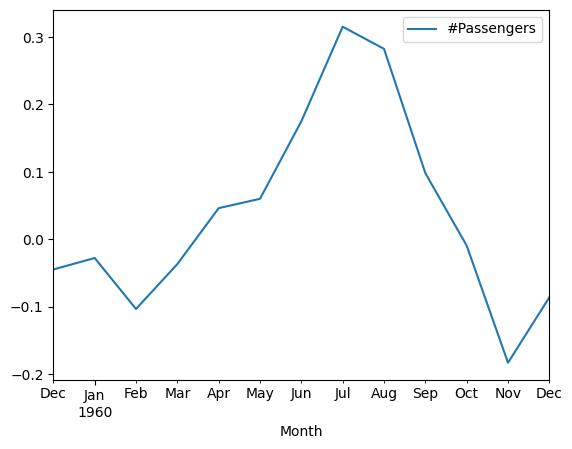

In [ ]:
test.plot()

<Axes: >

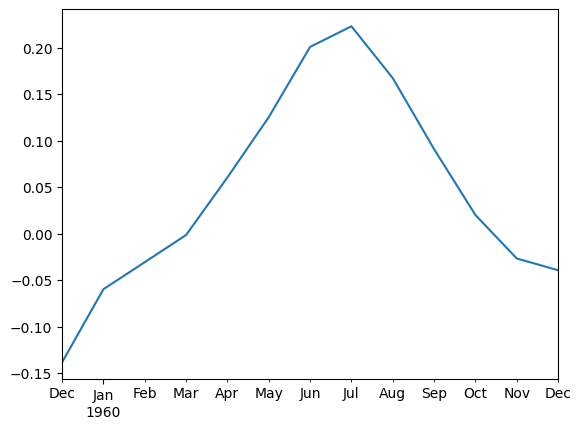

In [ ]:
prediction.plot()

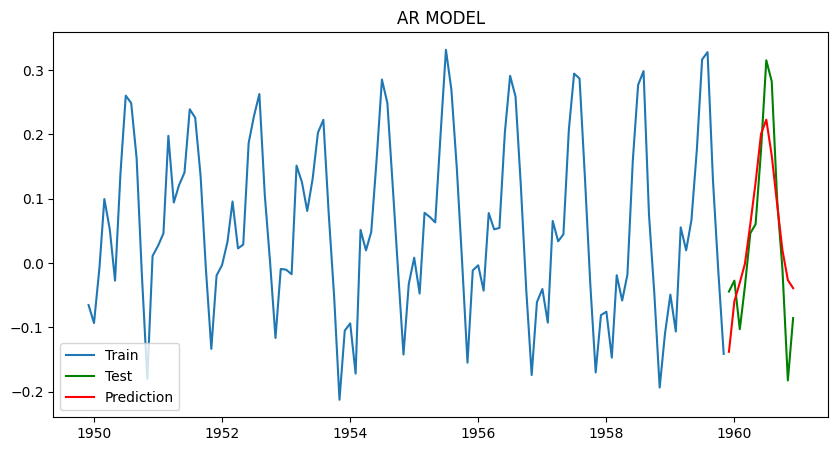

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(train,label="Train")
plt.plot(test.index,test,label="Test",color="green")
plt.plot(test.index,prediction,label="Prediction",color="red")
plt.legend()
plt.title("AR MODEL")
plt.show()

In [ ]:
newdata["ARPrediction"] = prediction

In [ ]:
newdata

,#Passengers,ARPrediction
Month,,
1949-12-01,-0.065494,NaN
1950-01-01,-0.093449,NaN
1950-02-01,-0.007566,NaN
1950-03-01,0.099416,NaN
1950-04-01,0.052142,NaN
...,...,...
1960-08-01,0.282363,0.167117
1960-09-01,0.098235,0.090790
1960-10-01,-0.009230,0.020062


<Axes: xlabel='Month'>

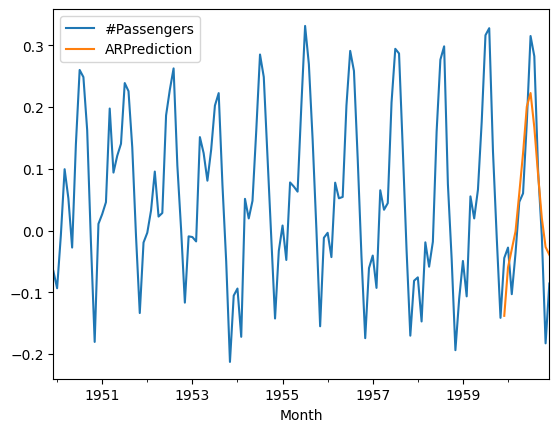

In [ ]:
newdata[["#Passengers","ARPrediction"]].plot()

In [ ]:
newdata.drop("ARPrediction",axis=1,inplace=True)

Moving Average

In [ ]:
#q => ACF plot

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

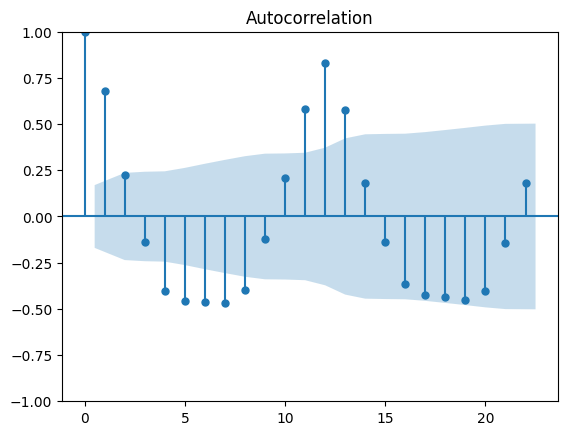

In [ ]:
plot_acf(newdata)
plt.show()

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
model = ARIMA(train,order=(0,0,11)) #(p,d,q)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
prediction = model_fit.predict(start=start,end=end)

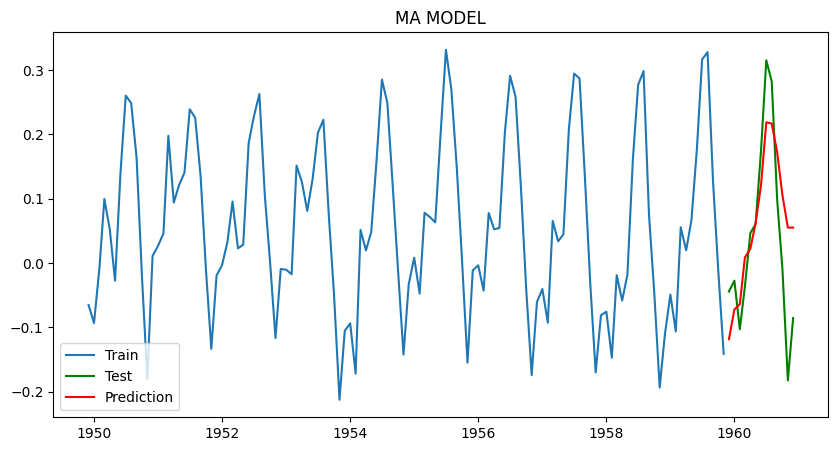

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(train,label="Train")
plt.plot(test.index,test,label="Test",color="green")
plt.plot(test.index,prediction,label="Prediction",color="red")
plt.legend()
plt.title("MA MODEL")
plt.show()

In [ ]:
model = ARIMA(train,order=(7,0,11))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
prediction =  model_fit.predict(start=start,end=end)

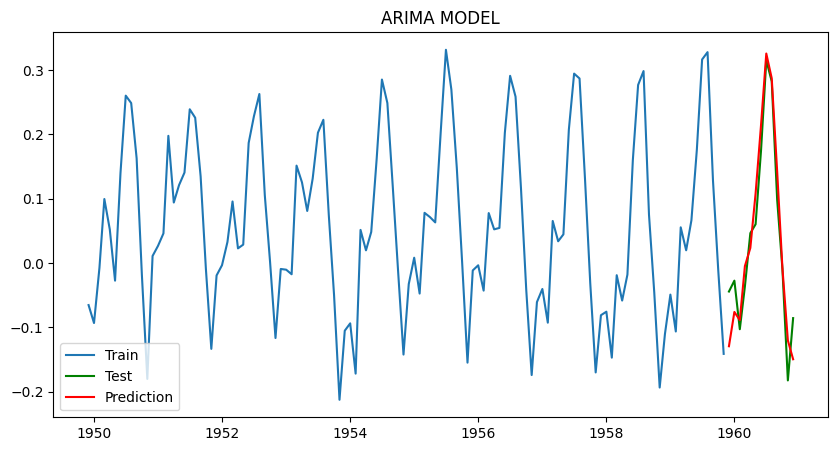

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(train,label="Train")
plt.plot(test.index,test,label="Test",color="green")
plt.plot(test.index,prediction,label="Prediction",color="red")
plt.legend()
plt.title("ARIMA MODEL")
plt.show()

In [ ]:
newdata

,#Passengers
Month,
1949-12-01,-0.065494
1950-01-01,-0.093449
1950-02-01,-0.007566
1950-03-01,0.099416
1950-04-01,0.052142
...,...
1960-08-01,0.282363
1960-09-01,0.098235
1960-10-01,-0.009230


In [ ]:
df

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [ ]:
train = df[:120]
test = df[120:]

In [ ]:
start = len(train)
end = len(train) + len(test) - 1

In [ ]:
model = ARIMA(train,order=(7,2,11))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
prediction = model_fit.predict(start=start,end=end)

In [ ]:
result = pd.DataFrame()
result["Actual"] = test
result["Predicted"] = prediction

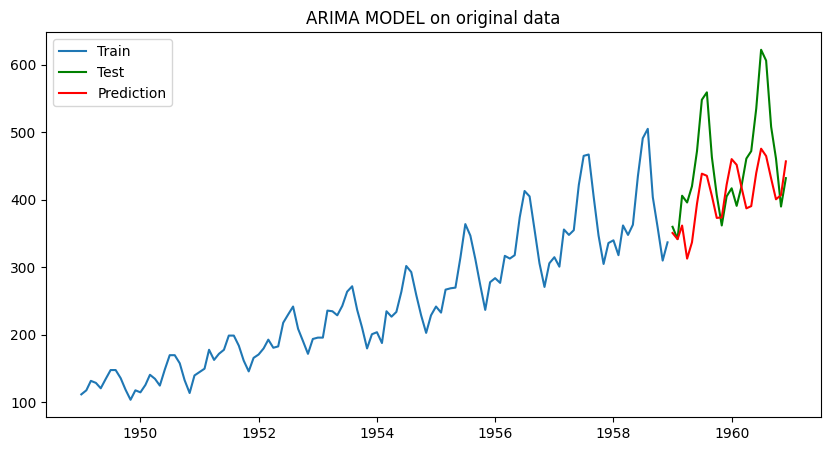

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(train,label="Train")
plt.plot(test.index,test,label="Test",color="green")
plt.plot(test.index,prediction,label="Prediction",color="red")
plt.legend()
plt.title("ARIMA MODEL on original data")
plt.show()

In [ ]:
result

,Actual,Predicted
Month,,
1959-01-01,360,350.862892
1959-02-01,342,341.653656
1959-03-01,406,361.845483
1959-04-01,396,312.925803
1959-05-01,420,337.030019
1959-06-01,472,394.154742
1959-07-01,548,438.632842
1959-08-01,559,435.511812
1959-09-01,463,405.806678


In [ ]:
import itertools

In [ ]:
p = range(4,12)
q = range(4,12)
d = range(0,3)

In [ ]:
pqd = list(itertools.product(p,d,q))

In [ ]:
len(pqd)

192

In [ ]:
from sklearn.metrics import *

In [ ]:
rmse = []
order = []
for i in pqd:
  model = ARIMA(train,order=i)
  model_fit = model.fit()
  pred = model_fit.predict(start=start,end=end)
  error = np.sqrt(mean_squared_error(test,pred))
  rmse.append(error)
  order.append(i)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Us

In [ ]:
result = pd.DataFrame(index=order,data=rmse,columns=["rmse"])

In [ ]:
result

,rmse
"(4, 0, 4)",118.583184
"(4, 0, 5)",72.863916
"(4, 0, 6)",219.064006
"(4, 0, 7)",100.149076
"(4, 0, 8)",110.898843
...,...
"(11, 2, 7)",50.927300
"(11, 2, 8)",52.446604
"(11, 2, 9)",50.190082
"(11, 2, 10)",48.960178


In [ ]:
result.sort_values(by="rmse",ascending=True)

,rmse
"(8, 2, 9)",30.849820
"(9, 2, 9)",31.809311
"(9, 2, 10)",33.041744
"(8, 2, 7)",37.088592
"(10, 2, 10)",43.536888
...,...
"(8, 0, 6)",202.750417
"(10, 0, 7)",209.041925
"(10, 0, 10)",209.139528
"(5, 0, 6)",218.362727


In [ ]:
model = ARIMA(train,order=(8,2,9))
model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
prediction = model_fit.predict(start=start,end=end)

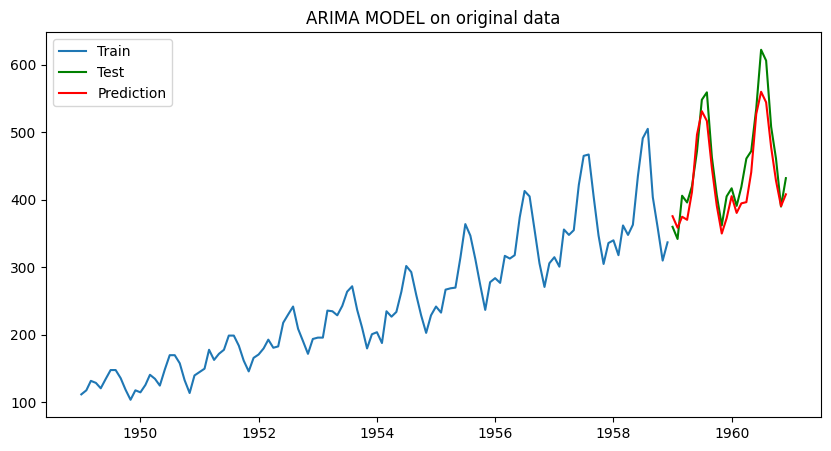

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(train,label="Train")
plt.plot(test.index,test,label="Test",color="green")
plt.plot(test.index,prediction,label="Prediction",color="red")
plt.legend()
plt.title("ARIMA MODEL on original data")
plt.show()

In [ ]:
df

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [ ]:
train

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1958-08-01,505
1958-09-01,404
1958-10-01,359


In [ ]:
test

,#Passengers
Month,
1959-01-01,360
1959-02-01,342
1959-03-01,406
1959-04-01,396
1959-05-01,420
1959-06-01,472
1959-07-01,548
1959-08-01,559
1959-09-01,463


In [ ]:
forecast = model_fit.forecast(steps=36)

In [ ]:
forecast

,predicted_mean
1959-01-01,375.704241
1959-02-01,358.601421
1959-03-01,374.909308
1959-04-01,370.357030
1959-05-01,411.641943
1959-06-01,496.399766
1959-07-01,531.111978
1959-08-01,516.755577
1959-09-01,447.139246
1959-10-01,391.554812


In [ ]:
print(test.index.freq)

None


In [ ]:
future_index = pd.date_range(
    start = test.index[0],
    periods = 36,
    freq = "MS"
)

In [ ]:
future_index

DatetimeIndex(['1959-01-01', '1959-02-01', '1959-03-01', '1959-04-01',
               '1959-05-01', '1959-06-01', '1959-07-01', '1959-08-01',
               '1959-09-01', '1959-10-01', '1959-11-01', '1959-12-01',
               '1960-01-01', '1960-02-01', '1960-03-01', '1960-04-01',
               '1960-05-01', '1960-06-01', '1960-07-01', '1960-08-01',
               '1960-09-01', '1960-10-01', '1960-11-01', '1960-12-01',
               '1961-01-01', '1961-02-01', '1961-03-01', '1961-04-01',
               '1961-05-01', '1961-06-01', '1961-07-01', '1961-08-01',
               '1961-09-01', '1961-10-01', '1961-11-01', '1961-12-01'],
              dtype='datetime64[ns]', freq='MS')

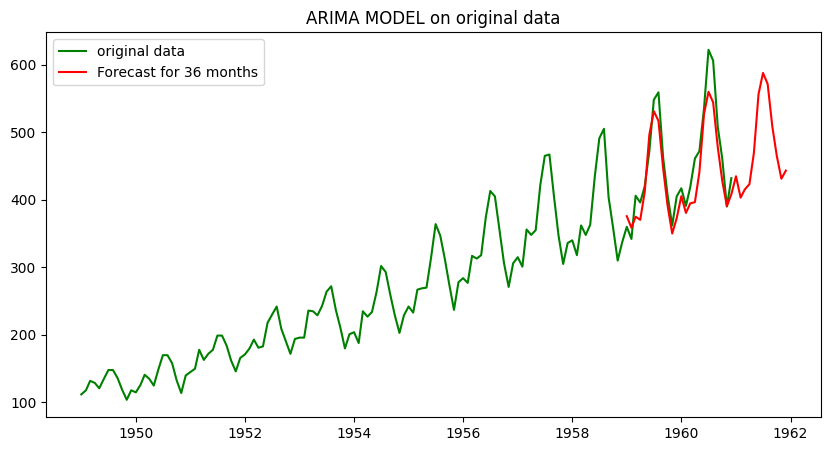

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df,label="original data",color="green")
plt.plot(future_index,forecast,label="Forecast for 36 months",color="red")
plt.legend()
plt.title("ARIMA MODEL on original data")
plt.show()

In [ ]:
df

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [ ]:
#p,d,q,s = > 8,2,9,12
#P,D,Q?


In [ ]:
dummydf = df.copy()

In [ ]:
dummydf

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [ ]:
seasonal_diff = dummydf.diff(12)

In [ ]:
seasonal_diff.head(24)

,#Passengers
Month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN
1949-06-01,NaN
1949-07-01,NaN
1949-08-01,NaN
1949-09-01,NaN


In [ ]:
seasonal_diff.dropna(inplace=True)

<Axes: xlabel='Month'>

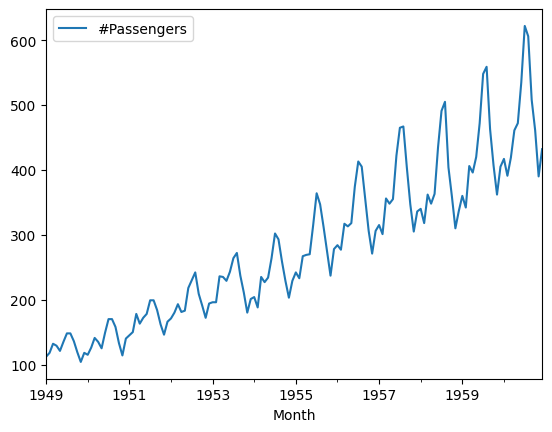

In [ ]:
df.plot()

<Axes: xlabel='Month'>

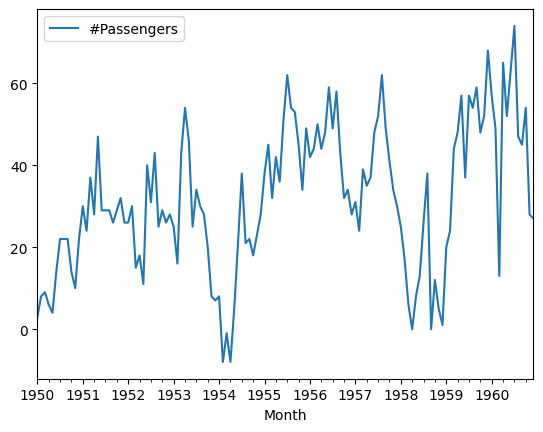

In [ ]:
seasonal_diff.plot()

In [ ]:
#D=1

In [ ]:
#P,Q

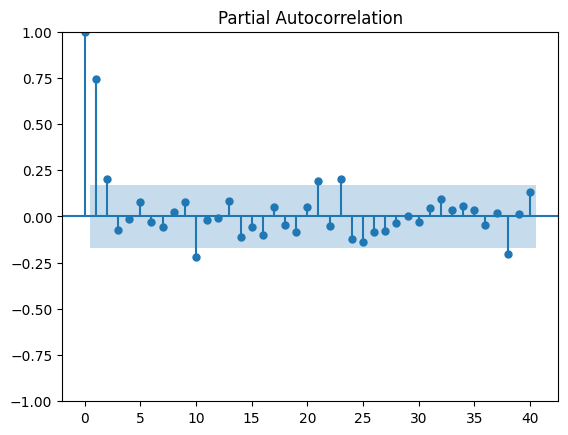

In [ ]:
plot_pacf(seasonal_diff,lags=40)
plt.show()

In [ ]:
#P = 1

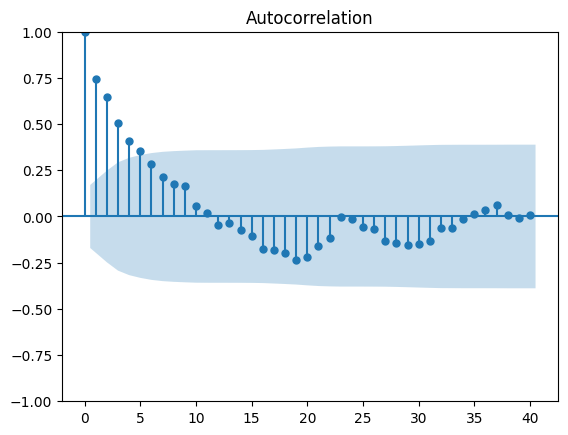

In [ ]:
plot_acf(seasonal_diff,lags=40)
plt.show()

In [ ]:
train.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [ ]:
#Q=1

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
model = SARIMAX(train,
    order = (8,2,9),
    seasonal_order = (8,2,9,12)
)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
model = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
prediction = model.predict(start = start,end = end)

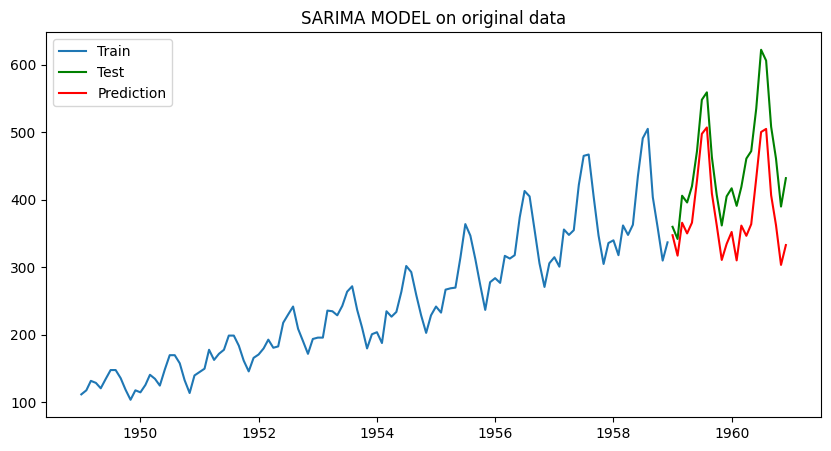

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(train,label="Train")
plt.plot(test.index,test,label="Test",color="green")
plt.plot(test.index,prediction,label="Prediction",color="red")
plt.legend()
plt.title("SARIMA MODEL on original data")
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# create sample time series data
np.random.seed(42)
date = pd.date_range(start="2020-01-01", periods=200, freq="D")
data = np.sin(np.arange(200)/10) + np.random.normal(0, 0.2, 200)

df = pd.DataFrame({"value": data}, index=date)

# train test split
train = df.iloc[:160]
test = df.iloc[160:]

In [ ]:
train

,value
2020-01-01,0.099343
2020-01-02,0.072181
2020-01-03,0.328207
2020-01-04,0.600126
2020-01-05,0.342588
...,...
2020-06-04,0.063597
2020-06-05,0.480909
2020-06-06,0.102730
2020-06-07,-0.330168


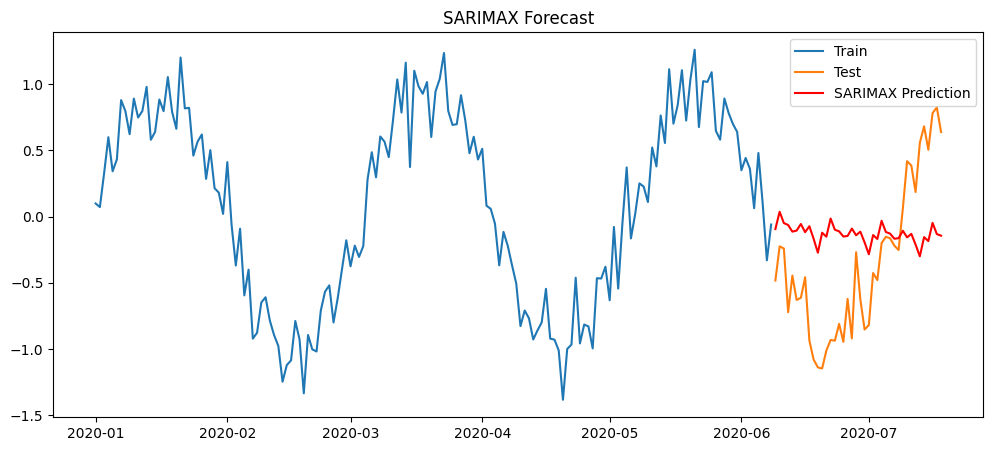

In [ ]:


# SARIMAX model (p,d,q) x (P,D,Q,s)
model = SARIMAX(
    train["value"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

result = model.fit()

# prediction
prediction = result.predict(
    start=test.index[0],
    end=test.index[-1]
)

# plot
plt.figure(figsize=(12,5))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(prediction, label="SARIMAX Prediction", color="red")
plt.legend()
plt.title("SARIMAX Forecast")
plt.show()

In [ ]:
# create exogenous variable
df["exog"] = np.random.normal(0, 1, len(df))


In [ ]:
df

,value,exog
2020-01-01,0.099343,0.357787
2020-01-02,0.072181,0.560785
2020-01-03,0.328207,1.083051
2020-01-04,0.600126,1.053802
2020-01-05,0.342588,-1.377669
...,...,...
2020-07-14,0.682603,-0.469176
2020-07-15,0.505192,-1.713135
2020-07-16,0.782318,1.353872
2020-07-17,0.825315,-0.114540


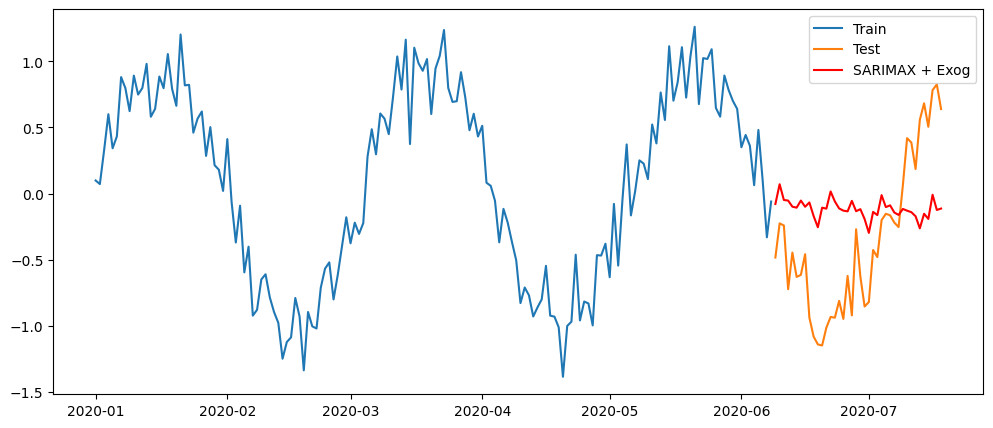

In [ ]:

train = df.iloc[:160]
test = df.iloc[160:]

model = SARIMAX(
    train["value"],
    exog=train[["exog"]],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

result = model.fit()

prediction = result.predict(
    start=test.index[0],
    end=test.index[-1],
    exog=test[["exog"]]
)

plt.figure(figsize=(12,5))
plt.plot(train["value"], label="Train")
plt.plot(test["value"], label="Test")
plt.plot(prediction, label="SARIMAX + Exog", color="red")
plt.legend()
plt.show()